In [ ]:
#defining everything
import numpy as np
import time
from Arm_Lib import Arm_Device
import cv2
from PIL import Image as im
import glob
import matplotlib.pyplot as plt
import sys
import math

#Dofbot/0.py_install/Arm_Lib/Arm_Lib.py

# Define the link lengths in meterss
l0 = 0.061   # base to servo 1
l1 = 0.0435  # servo 1 to servo 2
l2 = 0.08285 # servo 2 to servo 3
l3 = 0.08285 # servo 3 to servo 4
l4 = 0.07385 # servo 4 to servo 5
l5 = 0.05457 # servo 5 to gripper

# Define the base axis
ex = np.array([1, 0, 0]).T  # x axis
ey = np.array([0, 1, 0]).T  # y axis
ez = np.array([0, 0, 1]).T  # z axis
    
# Get DOFBOT object
Arm = Arm_Device()
time.sleep(.2)

#defining constants: 
#need to get camera calibration matrix

In [ ]:
def arm_move(q):
    Arm.Arm_serial_servo_write6(q[0], q[1], q[2], q[3], q[4], q[5], 2000)
    
def measure_arm(): 
    return np.array([Arm.Arm_serial_servo_read(1),Arm.Arm_serial_servo_read(2),Arm.Arm_serial_servo_read(3), Arm.Arm_serial_servo_read(4),Arm.Arm_serial_servo_read(5)])

In [2]:
#initilize arm configeration
initial_config = np.array([0, 90, 45, 35, 90, 145])
arm_move(initial_config)
time.sleep(0.5)

NameError: name 'np' is not defined

In [4]:
starting_config = np.array([Arm.Arm_serial_servo_read(1),Arm.Arm_serial_servo_read(2),Arm.Arm_serial_servo_read(3), Arm.Arm_serial_servo_read(4),Arm.Arm_serial_servo_read(5)])
print(starting_config)

NameError: name 'np' is not defined

In [570]:
#for picking color
#do this later
def color_correction(image):
    image_og = image
    #converts image to hsv
    hsv_image = cv2.cvtColor(image_og, cv2.COLOR_RGB2HSV)
    # Split the HSV channels
    h, s, v = cv2.split(hsv_image)
    # Increase the saturation channel
    saturation_factor = 1.4  # Adjust this factor to control the saturation increase
    s = np.clip(s * saturation_factor, 0, 255).astype(np.uint8)
    # Merge the HSV channels back
    hsv_image = cv2.merge([h, s, v])
    #adjustest overall brightness
    hsv_image[:, :, 2] = hsv_image[:, :, 2] * 0.9

    #trying to fix white balance
    #hsv_image[:,:,0] = hsv_image[:,:,0]/250*150 #blue channel
    #hsv_image[:,:,1] = hsv_image[:,:,1]/235*150 #green channel

    #so didn't have to do with camera? idk what it was doing

    # Convert the image back to BGR color space
    convert_RGB = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)

    x, y, w, h = 0, 0, 640, 400
    cropped = convert_RGB[y:y+h, x:x+w]

    #blurring image to reduce color noise
    blurred_rgb = cv2.GaussianBlur(cropped, (7, 7), 0)
    #final image output
    rgb_image = blurred_rgb
    
    return rgb_image
    
    #blurring image to reduce color noise
    blurred_rgb = cv2.GaussianBlur(convert_RGB, (7, 7), 0)
    #final image output
    rgb_image = blurred_rgb
    
    return rgb_image

In [571]:
def color_masking(image):
    rgb_image = image
    red_lower_rgb = np.array([100, 0, 0], np.uint8) 
    red_upper_rgb = np.array([255, 100, 100], np.uint8)
    red_mask_rgb = cv2.inRange(rgb_image, red_lower_rgb, red_upper_rgb)
    red_output_rgb = cv2.bitwise_and(rgb_image, rgb_image, mask = red_mask_rgb)
    #red_masked = cv2.cvtColor(rgb_image, cv2.COLOR_HSV2RGB) 

    #blue
    #values from yahboom
    #blue_lower_rgb = np.array([0, 0, 135], np.uint8) 
    #blue_upper_rgb = np.array([100, 100, 255], np.uint8) 
    blue_lower_rgb = np.array([0, 0, 104], np.uint8) 
    blue_upper_rgb = np.array([100, 100, 255], np.uint8) 
    #custom
    blue_mask_rgb = cv2.inRange(rgb_image, blue_lower_rgb, blue_upper_rgb)
    blue_output_rgb = cv2.bitwise_and(rgb_image, rgb_image, mask = blue_mask_rgb)
    #blue_masked = cv2.cvtColor(blue_output, cv2.COLOR_HSV2RGB) 
    
    #green
    #values from yahboom
    #green_lower_rgb = np.array([0, 50, 0], np.uint8) 
    #green_upper_rgb = np.array([100, 255, 100], np.uint8) 
    #custom
    green_lower_rgb = np.array([35, 60, 75], np.uint8) 
    green_upper_rgb = np.array([80, 255, 125], np.uint8) 
    green_mask_rgb = cv2.inRange(rgb_image, green_lower_rgb, green_upper_rgb)
    green_output_rgb = cv2.bitwise_and(rgb_image, rgb_image, mask = green_mask_rgb)
    #green_masked = cv2.cvtColor(green_output, cv2.COLOR_HSV2RGB)
    
    return red_mask_rgb, red_output_rgb, blue_mask_rgb, blue_output_rgb, green_mask_rgb, green_output_rgb

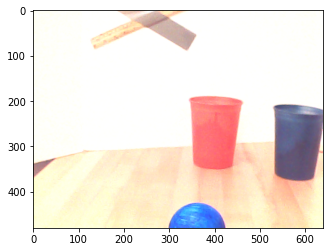

In [572]:
#capturing current field of view
camera = cv2.VideoCapture(0)
camera.set(5,10)
ret, image = camera.read()
image_og = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
camera.release()

plt.imshow(image_og)
plt.show()

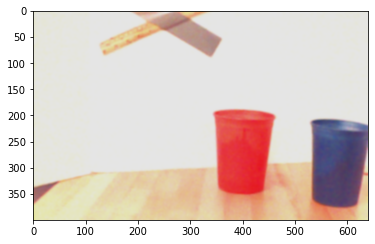

In [573]:
altered_im = color_correction(image_og)

plt.imshow(altered_im)
plt.show()

In [574]:
red_mask_array, red_mask_img, blue_mask_array, blue_mask_img, green_mask_array, green_mask_img = color_masking(altered_im) 

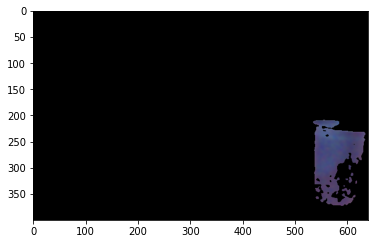

In [575]:
plt.imshow(blue_mask_img)
plt.show()

535
209
635
373


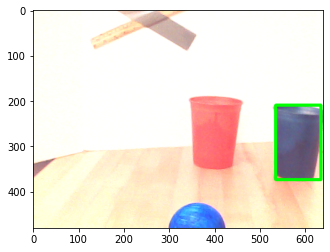

In [576]:
mask_blue = im.fromarray(blue_mask_img)
blue_bbox = mask_blue.getbbox()
lx, ly, rx, ry = blue_bbox
print(lx)
print(ly)
print(rx)
print(ry)
boxed_blue = image_og.copy()
boxed_blue = cv2.rectangle(boxed_blue, (lx, ly), (rx, ry), (0, 255, 0), 5)

plt.imshow(boxed_blue)
plt.show()

585
291


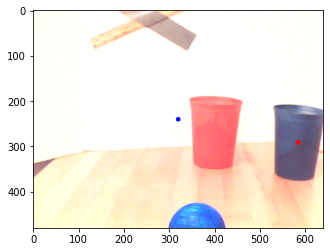

In [577]:
box_x_center = int((lx+rx)/2)
print(box_x_center)
box_y_center = int((ly+ry)/2)
print(box_y_center)

img_x_center = int(640/2)
img_y_center = int(480/2)

img_copy = image_og.copy()

circle_center = cv2.circle(img_copy, (box_x_center, box_y_center), 5, (255, 0, 0), -1)
circle_center = cv2.circle(img_copy, (img_x_center, img_y_center), 5, (0, 0, 255), -1)
plt.imshow(circle_center)
plt.show()

In [578]:
#original no scalar
cam_matrix = np.array([[1.0372e3, 0, 2.8098e2],
                      [0, 1.0373e3, 2.3956e2],
                      [0, 0, 1],])

theta = 9.5

z_dist = 0.9

world_x2 = ((box_x_center - cam_matrix[0, 2]) / cam_matrix[0, 0]) * z_dist
world_y2 = ((box_y_center - cam_matrix[1, 2]) / cam_matrix[1, 1]) * z_dist

world_y3 = (((box_y_center - cam_matrix[1, 2]) / cam_matrix[1, 1]) * z_dist) * math.sin(theta)
world_x3 = (((box_x_center - cam_matrix[0, 2]) / cam_matrix[0, 0]) * z_dist) - world_y3*math.cos(theta)

print(world_x2)
print(world_y2)
print(world_x3)
print(world_y3)


0.2638044735827227
0.044631254217680515
0.26045986965977075
-0.0033540887620745427


In [579]:
#real world is the difference in distance, if negative to the left, if positve to the right

#so they are the same...

adjustment_angle_rad = math.atan(world_x2/ z_dist)
adjustment_angle_rad_ii = math.atan(world_x3/ z_dist)

adj_ang_deg = math.degrees(adjustment_angle_rad)
print(adj_ang_deg)
adj_ang_deg_ii = math.degrees(adjustment_angle_rad_ii) * 0.70
print(adj_ang_deg_ii)

16.336709467075455
11.298304966453962


In [580]:
config = np.array([0, 90, 45, 35, 90, 145], dtype=np.float64)
config[0] = -adj_ang_deg_ii
print(config)

arm_move(config)
time.sleep(1)

[-11.29830497  90.          45.          35.          90.
 145.        ]


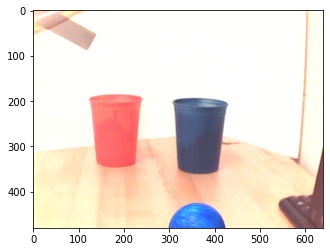

In [581]:
camera = cv2.VideoCapture(0)
camera.set(5,10)
ret, image = camera.read()
image_og = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
camera.release()

plt.imshow(image_og)
plt.show()

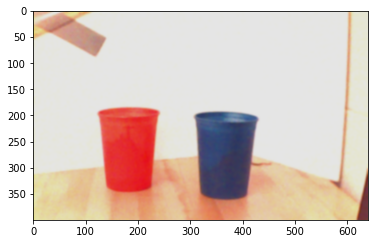

In [582]:
altered_im = color_correction(image_og)

plt.imshow(altered_im)
plt.show()

In [583]:
red_mask_array, red_mask_img, blue_mask_array, blue_mask_img, green_mask_array, green_mask_img = color_masking(altered_im) 

312
195
425
305


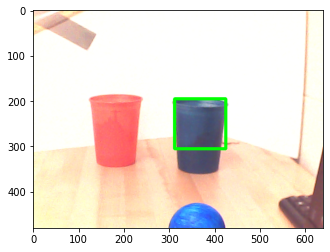

In [584]:
mask_blue = im.fromarray(blue_mask_img)
blue_bbox = mask_blue.getbbox()
lx, ly, rx, ry = blue_bbox
print(lx)
print(ly)
print(rx)
print(ry)
boxed_blue = image_og.copy()
boxed_blue = cv2.rectangle(boxed_blue, (lx, ly), (rx, ry), (0, 255, 0), 5)

plt.imshow(boxed_blue)
plt.show()

368
250


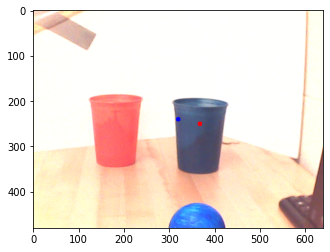

In [585]:
box_x_center = int((lx+rx)/2)
print(box_x_center)
box_y_center = int((ly+ry)/2)
print(box_y_center)

img_x_center = int(640/2)
img_y_center = int(480/2)

img_copy = image_og.copy()

circle_center = cv2.circle(img_copy, (box_x_center, box_y_center), 5, (255, 0, 0), -1)
circle_center = cv2.circle(img_copy, (img_x_center, img_y_center), 5, (0, 0, 255), -1)
plt.imshow(circle_center)
plt.show()

In [586]:
#need to align with zero, only issue is not being able to read angle above 180
#but cannot go back to negative 90 - just one move no correction hope for best

if config[0] < 0:
    config[0] += 180
else:
    config[0] -= 180

#so if negative need to add 180, if postive need to subjectract 180checking
arm_move(config)
time.sleep(1)

In [587]:
#moving arm back to throw

q2_cock = 45
q3_cock = 40
q4_cock = 90

config[[1, 2, 3]] = [q2_cock, q3_cock, q4_cock]
print(config)

arm_move(config)

time.sleep(1)



[168.70169503  45.          40.          90.          90.
 145.        ]


In [588]:

q2_throw = 90
q3_throw = 100

config[[1, 2]] = [q2_throw, q3_throw]
print(config)

q = config

Arm.Arm_serial_servo_write6(q[0], q[1], q[2], q[3], q[4], q[5], 1)



[168.70169503  90.         100.          90.          90.
 145.        ]
